# Limpieza de datos previa

In [1]:
import os
os.chdir("..")
from src.utils.detectar_espanol_fasttext import detectar_espanol_fasttext
from src.utils.detectar_idioma_lang import detectar_idioma_lang
from src.utils.detectar_idoma_lingua import detectar_idoma_lingua
from src.utils.quitar_emojis import quitar_emojis
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

## Arenal y Manuel

In [2]:
arenal = pd.read_csv("data/raw/reseñas_arenal.csv")
manuel = pd.read_csv("data/raw/manuel.csv")

cols_outscraper = ['name', 'author_title','reviews', 'review_rating', 'review_text' , 'review_datetime_utc', 'author_image']

manuel = manuel[cols_outscraper]
arenal = arenal[cols_outscraper]

new_cols = {
    'name': 'business_name',
    'author_title': 'author_title',
    'reviews': 'total_reviews',
    'review_rating': 'review_rating',
    'review_text': 'review_text',
    'review_datetime_utc': 'datetime_utc',
    'author_image': 'author_image'
}

manuel = manuel.rename(columns=new_cols)
arenal = arenal.rename(columns=new_cols)

manuel.head(3)

,business_name,author_title,total_reviews,review_rating,review_text,datetime_utc,author_image
0,Parque Nacional Manuel Antonio,Dr Annie Janvier,24467,3,Touristy and very overrated. Many other great ...,06/05/2026 05:46:47,https://lh3.googleusercontent.com/a-/ALV-UjXwD...
1,Parque Nacional Manuel Antonio,ASB ASB,24467,5,"Increíble!! Lleno de flora y fauna del país, c...",06/05/2026 03:38:27,https://lh3.googleusercontent.com/a/ACg8ocKjXk...
2,Parque Nacional Manuel Antonio,Greyson García Arias,24467,5,NaN,06/04/2026 21:58:36,https://lh3.googleusercontent.com/a-/ALV-UjUwZ...


## Ruinas y Museo de los niños

In [3]:
ruinas = pd.read_csv("data/raw/ruinas.csv", sep=";")
museo = pd.read_csv("data/raw/museo.csv", sep=";")

cols_hasData = ["rating", "isoDate", "snippet", "userName", "userThumbnail"]
ruinas = ruinas[cols_hasData]
museo = museo[cols_hasData]

ruinas['business_name'] = 'Ruinas de la Parroquia de Santiago Apóstol'
museo['business_name'] = 'Museo de los Niños'

ruinas ['total_reviews']= 4035
museo ['total_reviews']= 19245

ruinas["isoDate"] = pd.to_datetime(ruinas["isoDate"])
ruinas["isoDate"] = ruinas["isoDate"].dt.strftime("%d/%m/%Y %H:%M:%S")

museo["isoDate"] = pd.to_datetime(museo["isoDate"])
museo["isoDate"] = museo["isoDate"].dt.strftime("%d/%m/%Y %H:%M:%S")

nuevas_hasData = {
    'userName': 'author_title',
    'reviews': 'total_reviews',
    'review_rating': 'review_rating',
    'snippet': 'review_text',
    'isoDate': 'datetime_utc',
    'userThumbnail': 'author_image',
    'rating': 'review_rating'
}

ruinas = ruinas.rename(columns=nuevas_hasData)
museo = museo.rename(columns=nuevas_hasData)
museo.tail(3)

,review_rating,datetime_utc,review_text,author_title,author_image,business_name,total_reviews
187,5,05/11/2025 19:23:19,"El teatro es espectacular, la acústica inmejor...",Francisco Frias,https://lh3.googleusercontent.com/a-/ALV-UjW7W...,Museo de los Niños,19245
188,4,05/11/2025 12:33:29,NaN,Dany Villalobos Elizondo,https://lh3.googleusercontent.com/a-/ALV-UjUaQ...,Museo de los Niños,19245
189,4,30/10/2025 18:13:46,El servicio al cliente de la chica de lentes ...,Karol,https://lh3.googleusercontent.com/a-/ALV-UjWmc...,Museo de los Niños,19245


## Kalambu

In [4]:
kalambu = pd.read_csv("data/raw/kalambu.csv")
cols_livescraper = ['business_name', 'author_title', 'total_reviews', 'review_rating', 'review_text', 'review_datetime_utc', 'author_image']
kalambu = kalambu[cols_livescraper]
kalambu = kalambu.rename(columns={'review_datetime_utc': 'datetime_utc'})
kalambu.head(2)


,business_name,author_title,total_reviews,review_rating,review_text,datetime_utc,author_image
0,Kalambu Hot Springs,Gilberto Guevara,4350,5,Increíble combinación de adrenalina y relajaci...,2026-02-26 00:24:29,https://lh3.googleusercontent.com/a-/ALV-UjUA0...
1,Kalambu Hot Springs,Sonia,4350,5,"Muy bonito,mi familia se divirtió muchisimo☀️💦...",2025-12-16 12:09:53,https://lh3.googleusercontent.com/a/ACg8ocIcaL...


## Concatenación

In [5]:
resenias = pd.concat([arenal, manuel, kalambu, ruinas, museo], ignore_index=True, join='inner')
print(len(resenias))
resenias.head(2)

2020


,business_name,author_title,total_reviews,review_rating,review_text,datetime_utc,author_image
0,Volcán Arenal,Daniel Martínez,1626,5,No sé cómo explicar la belleza incomparable de...,02/10/2026 14:39:19,https://lh3.googleusercontent.com/a-/ALV-UjX34...
1,Volcán Arenal,Jose Rambaud,1626,5,Volcán activo en parque nacional homónimo en A...,09/29/2025 19:00:19,https://lh3.googleusercontent.com/a-/ALV-UjWcm...


In [6]:
resenias = resenias.dropna(subset=['review_text'])
print(len(resenias))

1486


## Deteccion de idiomas

### Langdetect

In [7]:
resenias['review_text'] = resenias['review_text'].apply(quitar_emojis)
resenias['review_text'] = resenias['review_text'].apply(lambda x: ' '.join(x.split()))

resenias['idioma_langd'] = resenias['review_text'].apply(detectar_idioma_lang)
resenias[['review_text','idioma_langd']].head(3)

,review_text,idioma_langd
0,No sé cómo explicar la belleza incomparable de...,es
1,Volcán activo en parque nacional homónimo en A...,es
2,"Bello parque nacional con vistas al volcan,her...",es


### Fasttext

In [8]:
resenias['es_espanol'] = resenias['review_text'].apply(detectar_espanol_fasttext)
resenias[['es_espanol', 'review_text']].head(3)

,es_espanol,review_text
0,True,No sé cómo explicar la belleza incomparable de...
1,True,Volcán activo en parque nacional homónimo en A...
2,True,"Bello parque nacional con vistas al volcan,her..."


### Comparación

In [9]:
fasttext_esp = resenias[resenias['es_espanol'] == True]
langdetect_esp = resenias[resenias['idioma_langd'] == 'es']

print(len(fasttext_esp))
print(len(langdetect_esp))

890
1039


In [10]:
idx_solo_df1 = fasttext_esp.index.difference(langdetect_esp.index)  # Resultado: Int64Index([10, 20])

# 2. Encontrar los índices que están en df2 pero NO en df1
idx_solo_df2 = langdetect_esp.index.difference(fasttext_esp.index)  # Resultado: Int64Index([50, 60])

# 3. Extraer las filas exclusivas de cada uno
exclusivos_df1 = fasttext_esp.loc[idx_solo_df1]
exclusivos_df2 = langdetect_esp.loc[idx_solo_df2]

# 4. (Opcional) Si quieres un solo DataFrame con TODOS los elementos no compartidos:
todos_los_exclusivos = pd.concat([exclusivos_df1, exclusivos_df2])
with pd.option_context('display.width', 2000, 'display.max_colwidth', None):
    display(todos_los_exclusivos[['review_text','idioma_langd','es_espanol']].head(5))

,review_text,idioma_langd,es_espanol
154,Me gusta la ap,ca,True
199,Nublado hoy,so,True
203,Demasiado lindo para ver el atardecer,pt,True
206,Bello hay q revisar clima,it,True
337,Sitio increíble,en,True


In [11]:
resenias_langd = resenias[resenias['idioma_langd'] == 'es']
extanjeras = resenias[resenias['idioma_langd'] != 'es']

extanjeras[['review_text','idioma_langd']].head(5) #267

,review_text,idioma_langd
109,Excelente bonito. Full calor,it
140,Hermoso e imponente,it
154,Me gusta la ap,ca
163,Impresionante la vista del coloso,it
176,Hermoso,en


### Lingua

Es utilizada para detectar idiomas en textos cortos

In [12]:
extanjeras['idioma_lingua'] = extanjeras['review_text'].apply(detectar_idoma_lingua)

with pd.option_context('display.width', 2000, 'display.max_colwidth', None):
    display(extanjeras[['review_text', 'idioma_lingua']].head(3))

,review_text,idioma_lingua
109,Excelente bonito. Full calor,pt
140,Hermoso e imponente,es
154,Me gusta la ap,es


## Corpus en español

In [13]:
resenias_esp = pd.concat([extanjeras[extanjeras['idioma_lingua'] == 'es'], resenias_langd], ignore_index=True)
resenias_esp = resenias_esp.drop(columns=['idioma_lingua', 'es_espanol','idioma_langd'])
resenias_esp['datetime_utc'] = resenias_esp['datetime_utc'].str.replace('-', '/')
print(len(resenias_esp))
resenias_esp.sample(3)

1120


,business_name,author_title,total_reviews,review_rating,review_text,datetime_utc,author_image
528,Parque Nacional Manuel Antonio,Gissell Gonzalez Cuzzi,24467,4,El parque destaca principalmente por su entorn...,03/05/2026 03:07:40,https://lh3.googleusercontent.com/a-/ALV-UjVtL...
516,Parque Nacional Manuel Antonio,Karolina Sequeira Jimenez,24467,5,Debo decir que me sorprendió demasiado la reno...,03/11/2026 22:28:41,https://lh3.googleusercontent.com/a-/ALV-UjUJc...
956,Ruinas de la Parroquia de Santiago Apóstol,YEAK,4035,3,"Bonito por fuera por dentro no, huele a orines...",18/03/2026 15:10:41,https://lh3.googleusercontent.com/a-/ALV-UjWuy...


In [14]:
resenias_esp.to_csv('data/processed/resenas_clean.csv',  sep=';',index=False)

# Exploracion de datos

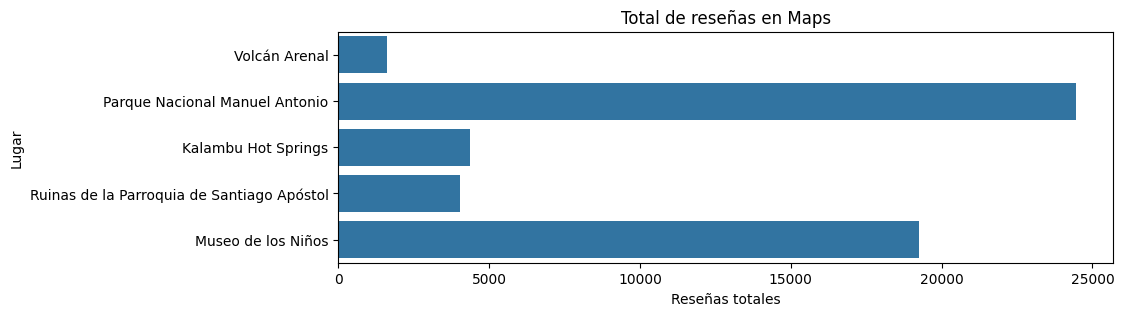

In [15]:
total_resenias_lugares  = resenias_esp[['business_name', 'total_reviews']]
total_resenias_lugares = total_resenias_lugares.drop_duplicates()

plt.figure(figsize=(10, 3))
sns.barplot(y='business_name', x='total_reviews', data=total_resenias_lugares)

plt.xlabel('Reseñas totales')
plt.ylabel('Lugar')
plt.title('Total de reseñas en Maps');

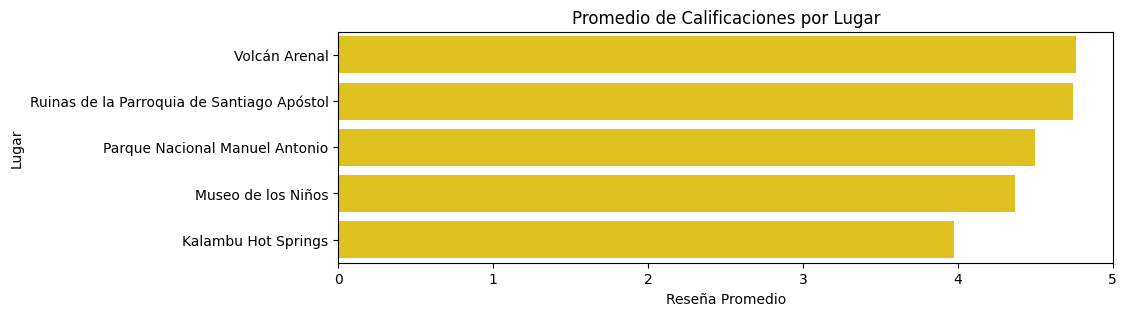

In [16]:
df_rating = (
    resenias_esp.groupby(["business_name"])["review_rating"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 3))
sns.barplot(x="review_rating", y="business_name", data=df_rating, color="gold")

plt.title("Promedio de Calificaciones por Lugar")
plt.xlabel("Reseña Promedio")
plt.ylabel("Lugar");

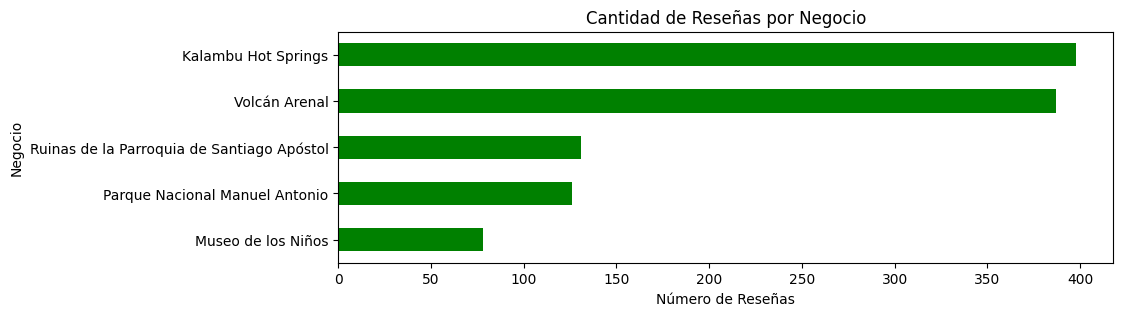

In [19]:
conteo_resenias = (
    resenias_esp.groupby(["business_name"])
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 3))
conteo_resenias.plot(kind="barh", color="green")

plt.gca().invert_yaxis()
plt.title("Cantidad de Reseñas por Negocio")
plt.xlabel("Número de Reseñas")
plt.ylabel("Negocio");

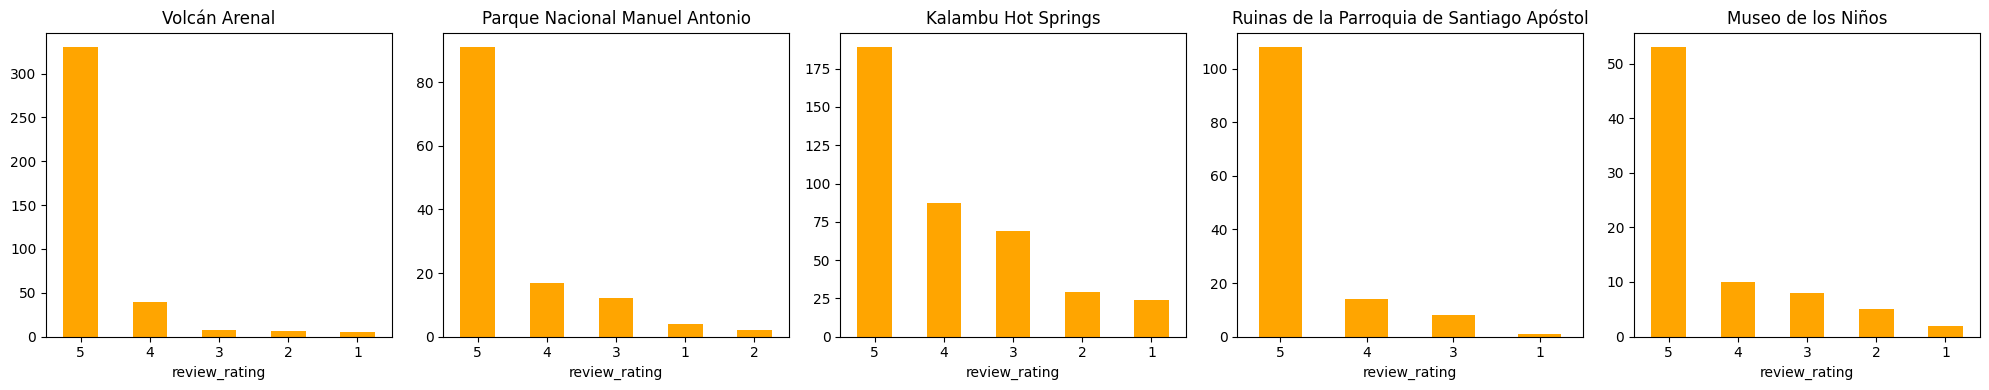

In [18]:
negocios = resenias_esp['business_name'].unique()

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, negocio in enumerate(negocios):
    ax = axes[i]
    resenias_esp[resenias_esp['business_name'] == negocio]['review_rating'].value_counts().plot(kind='bar', ax=ax, rot=0, color='orange')
    ax.set_title(negocio)

plt.tight_layout()
plt.show()